In [1]:
import qiskit

In [2]:
qiskit.__version__

'1.3.2'

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service=QiskitRuntimeService(channel= "ibm_quantum",
                             token = "235b0c8a54de46cc1c6997486aac5a977ecd7304cd3fa5759c9cb4d2cff12c30c4afcb4aa15b77d79be2882ce93795a51d19b5cb9729d71ca76a481c1086aad9")

In [ ]:
backend = service.backend(name='ibm_brisbane')

In [16]:
import numpy as np
# Add these lines at the start of your notebook
%matplotlib inline
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp
from qiskit.circuit.library import RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from IPython.display import HTML
import json



In [17]:
#------------------- Data Loading -------------------
def get_real_weather_data_from_file(file_path):
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
        values = np.array([entry.get("value", 0) for entry in data])
        values = np.nan_to_num(values, nan=0.0)
        values = np.clip(values, 0, None)
        return values
    except Exception as e:
        print(f"Error loading data: {e}")
        return np.zeros(24)

file_path = "C:\\Users\\sanje\\cwq\\gwa-plot-data_2025-04-04174378832547705_38_45_UTC\\diurnalData.json"
wind_speeds = get_real_weather_data_from_file(file_path)
timesteps = min(24, len(wind_speeds))

In [18]:
# ------------------- Grid Setup -------------------
nx, ny = 50, 50  # Reduced grid size
x = np.linspace(0, 10, nx)
y = np.linspace(0, 10, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]


In [19]:
# ------------------- Initial Conditions -------------------
def generate_initial_conditions(wind_init, nx, ny):
    u0 = np.outer(np.sin(np.pi * y / 10), np.ones_like(x)) * (wind_init / np.max(np.sin(np.pi * y / 10)))
    v0 = np.zeros_like(u0)
    p0 = np.zeros_like(u0)
    for i in range(1, ny-1):
        p0[i, :] = p0[i-1, :] - dy * (u0[i, :] ** 2 + v0[i, :] ** 2) / 2
    u0[0, :] = u0[-1, :] = 0
    v0[0, :] = v0[-1, :] = 0
    return u0, v0, p0

wind_init = wind_speeds[0]
u0, v0, p0 = generate_initial_conditions(wind_init, nx, ny)
y0 = np.hstack([u0.flatten(), v0.flatten(), p0.flatten()])


In [20]:
class QuantumPDESolver:
    def __init__(self, num_qubits=4, reps=2):
        self.num_qubits = num_qubits
        self.ansatz = RealAmplitudes(num_qubits=num_qubits, reps=reps)
        self.optimizer = COBYLA(maxiter=100)
        self.estimator = StatevectorEstimator()

    def create_quantum_hamiltonian(self, grid_size):
        num_qubits = min(self.num_qubits, grid_size)
        terms = []

        for i in range(num_qubits):
            pauli_str = ['I'] * num_qubits
            pauli_str[i] = 'Z'
            terms.append((''.join(pauli_str), 1.0))

        if num_qubits > 1:
            for i in range(num_qubits - 1):
                pauli_str = ['I'] * num_qubits
                pauli_str[i] = 'X'
                pauli_str[i + 1] = 'X'
                terms.append((''.join(pauli_str), 0.5))

        return SparsePauliOp.from_list(terms)

    def solve(self, initial_state, t_span, shape):
        H = self.create_quantum_hamiltonian(shape[0])

        def quantum_cost(params):
            try:
                param_dict = dict(zip(self.ansatz.parameters, params))
                circuit = self.ansatz.assign_parameters(param_dict)
                expectation = self.estimator.run(
                    circuits=[circuit],
                    observables=[H]
                ).result().values[0]
                return np.real(expectation)
            except Exception as e:
                print(f"Quantum circuit evaluation error: {e}")
                return float('inf')

        num_params = len(self.ansatz.parameters)
        initial_params = np.random.random(num_params) * 2 * np.pi

        result = self.optimizer.minimize(
            fun=quantum_cost,
            x0=initial_params,
            bounds=[(0, 2 * np.pi)] * num_params
        )
        return result



In [21]:
# ------------------- Navier-Stokes -------------------
RHO = 1.0
NU = 0.01  # High viscosity for numerical stability
DT = 0.1
call_count = 0


def navier_stokes_3D(t, Y, shape, nu=NU, rho=RHO):
    global call_count
    call_count += 1

    U = Y.reshape((3,) + shape)
    u, v, w = U

    if np.isnan(U).any() or np.abs(U).max() > 1e6:
        raise ValueError(f"Unstable values at t={t:.4f}: max={np.abs(U).max()}, min={U.min()}")

    du_dx = np.gradient(u, axis=0)
    du_dy = np.gradient(u, axis=1)
    du_dz = np.gradient(u, axis=2)

    dv_dx = np.gradient(v, axis=0)
    dv_dy = np.gradient(v, axis=1)
    dv_dz = np.gradient(v, axis=2)

    dw_dx = np.gradient(w, axis=0)
    dw_dy = np.gradient(w, axis=1)
    dw_dz = np.gradient(w, axis=2)

    laplacian_u = sum(np.gradient(np.gradient(u, axis=i), axis=i) for i in range(3))
    laplacian_v = sum(np.gradient(np.gradient(v, axis=i), axis=i) for i in range(3))
    laplacian_w = sum(np.gradient(np.gradient(w, axis=i), axis=i) for i in range(3))

    du_dt = -u * du_dx - v * du_dy - w * du_dz + nu * laplacian_u
    dv_dt = -u * dv_dx - v * dv_dy - w * dv_dz + nu * laplacian_v
    dw_dt = -u * dw_dx - v * dw_dy - w * dw_dz + nu * laplacian_w

    # Damping to prevent blow-up
    du_dt -= 0.05 * u
    dv_dt -= 0.05 * v
    dw_dt -= 0.05 * w

    dU_dt = np.stack([du_dt, dv_dt, dw_dt])
    return dU_dt.flatten()

# ------------------- Initial Conditions -------------------
shape = (4, 4, 4)
u0 = np.random.rand(*shape) * 0.1
v0 = np.random.rand(*shape) * 0.1
w0 = np.random.rand(*shape) * 0.1
y0 = np.stack([u0, v0, w0]).flatten()
timesteps = 10

# ------------------- Solve -------------------
t_eval = np.linspace(0, timesteps - 1, 10)
qpde_solver = QuantumPDESolver(num_qubits=4, reps=2)

try:
    sol = solve_ivp(
        navier_stokes_3D,
        [0, timesteps - 1],
        y0,
        args=(u0.shape, NU, RHO),
        t_eval=t_eval,
        method='BDF',  # Robust stiff solver
        rtol=1e-3,
        atol=1e-5
    )
    if not sol.success:
        raise RuntimeError(f"Integration failed: {sol.message}")
    print("Simulation completed successfully.")
except Exception as e:
    print(f"Error during integration: {e}")
    sol = None


Simulation completed successfully.


In [23]:
# ------------------- Postprocessing -------------------
if sol is not None and sol.success:
    n = u0.size
    frames = len(t_eval)
    u_sim = np.zeros((u0.shape[0], u0.shape[1], u0.shape[2], frames))
    v_sim = np.zeros_like(u_sim)
    p_sim = np.zeros_like(u_sim)

    for i in range(frames):
        u_sim[..., i] = sol.y[:n, i].reshape(u0.shape)
        v_sim[..., i] = sol.y[n:2*n, i].reshape(u0.shape)
        p_sim[..., i] = sol.y[2*n:, i].reshape(u0.shape)
else:
    print("Error: solve_ivp failed or returned None.")
    u_sim = np.zeros((u0.shape[0], u0.shape[1], u0.shape[2], len(t_eval)))
    v_sim = np.zeros_like(u_sim)
    p_sim = np.zeros_like(u_sim)


Simulation Metrics:
Mean Wind Speed: 0.0703
Max Pressure: 1.5735


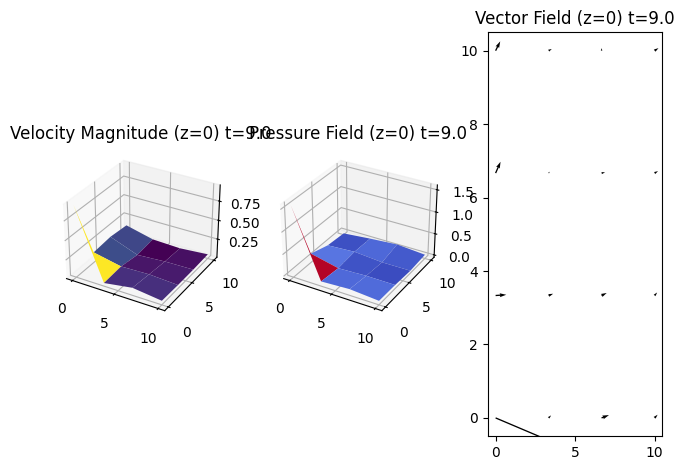

In [26]:
# ------------------- Simplified Visualization -------------------
fig = plt.figure(figsize=(15, 5))

# Create a meshgrid matching the simulation data shape (4x4)
x_small = np.linspace(0, 10, u_sim.shape[0])
y_small = np.linspace(0, 10, u_sim.shape[1])
X_small, Y_small = np.meshgrid(x_small, y_small)

def update(frame):
    plt.clf()
    
    # Choose a slice index along the z-axis for visualization
    z_slice = 0  # You can change this to visualize other slices

    # Velocity field plot (2D slice)
    ax1 = plt.subplot(131, projection='3d')
    vel_mag = np.sqrt(u_sim[:,:,z_slice,frame]**2 + v_sim[:,:,z_slice,frame]**2)
    ax1.plot_surface(X_small, Y_small, vel_mag, cmap='viridis')
    ax1.set_title(f'Velocity Magnitude (z={z_slice}) t={t_eval[frame]}')
    
    # Pressure field plot (2D slice)
    ax2 = plt.subplot(132, projection='3d')
    ax2.plot_surface(X_small, Y_small, p_sim[:,:,z_slice,frame], cmap='coolwarm')
    ax2.set_title(f'Pressure Field (z={z_slice}) t={t_eval[frame]}')
    
    # Vector field plot (2D slice)
    ax3 = plt.subplot(133)
    skip = 1  # No skipping needed for 4x4 grid
    ax3.quiver(X_small[::skip,::skip], Y_small[::skip,::skip],
               u_sim[::skip,::skip,z_slice,frame],
               v_sim[::skip,::skip,z_slice,frame])
    ax3.set_title(f'Vector Field (z={z_slice}) t={t_eval[frame]}')
    
    plt.tight_layout()
    return fig,

# Create and display animation
anim = animation.FuncAnimation(fig, update, frames=len(t_eval),
                             interval=300, blit=True)

plt.close()
display(HTML(anim.to_jshtml()))

# Print basic metrics
print("\nSimulation Metrics:")
print(f"Mean Wind Speed: {np.mean(np.sqrt(u_sim**2 + v_sim**2)):.4f}")
print(f"Max Pressure: {np.max(p_sim):.4f}")